In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 26.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.optimize import minimize

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
plt_df_raw = pd.read_csv('number_of_mouse_ct_found.csv', index_col = 'Unnamed: 0')

In [ ]:
#Loading Data

In [28]:
fn = 'Active_SAMap_Joined/active_samap/sm_Allen_Full_xt_slc17a6_cleaned_03122025_subclass_250.pkl'
fn_mo = 'Active_SAMap_Joined/active_samap/sm_mo_xt_cleaned_03122025.pkl'

In [29]:
org = 'xt'
ref_one = 'mg'
ref_two = 'mo'

In [30]:
sm = load_samap(fn)
sm_mo = load_samap(fn_mo)

In [176]:
#setting mo labels to known labels

In [31]:
level = 'fin_ct'

In [32]:
fin_labs = pd.read_csv('Active_SAMap_Joined/MO_subclass_id_label_mapping_boostrap_th9_03192025.csv', index_col = 'Unnamed: 0')

In [33]:
len(fin_labs['fin_ct'].unique())

115

In [34]:
len(fin_labs['fin_ct'][fin_labs['fin_ct'] == 'Unlabeled'])

11176

In [35]:
len(fin_labs)

75330

In [36]:
sm_mo.sams['mo'].adata.obs['subclass_id_label_mapping'] = fin_labs['fin_ct']

In [ ]:
#mapping 

In [ ]:
for reso in range(5,80,5):
    print(reso)
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + str(int((reso/5)*(100/15))) + ' precent')

    fx = [i for i in range(5,80,5)]
    func = np.polyfit(np.log(x), num_cell_types, 1)
    plt.plot([i for i in range(5,80,5)], [func[0] * np.log(i) + func[1] for i in range(5,80,5)])
    plt.scatter(x, num_cell_types)
    plt.show()

5
99
52
20.495057582855225 seconds to complete 6 precent
10
119
55
42.00160074234009 seconds to complete 13 precent
15
132
57
64.61510181427002 seconds to complete 20 precent
20
137
56
87.8892457485199 seconds to complete 26 precent
25
142
57
111.82804608345032 seconds to complete 33 precent
30
146
57
136.22040176391602 seconds to complete 40 precent
35
153
57
161.27646732330322 seconds to complete 46 precent
40
154
58
186.62046146392822 seconds to complete 53 precent
45
158
57
212.59063386917114 seconds to complete 60 precent
50
158
59
238.80640625953674 seconds to complete 66 precent
55
158
60
265.5902216434479 seconds to complete 73 precent
60
159
60
292.8689777851105 seconds to complete 80 precent
65
158
58
320.7239770889282 seconds to complete 86 precent
70
161
59
348.9252905845642 seconds to complete 93 precent
75
161
59
377.6831669807434 seconds to complete 100 precent


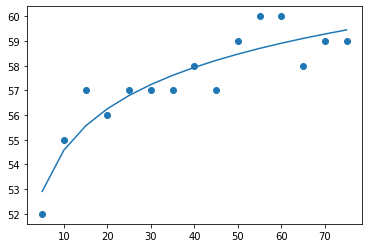

In [41]:
for i in range(30):
    num_ct_mapped = 0
    t0 = time.time()
    level = 'subclass_id_label'
    num_cell_types = []
    reso = #add best resolution here
    
    #clustering the mg to org data
    sm.sams[org].clustering(param = reso)

    # mapping from mg to org data
    keys = {ref_one:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_one)]

    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref_one + '_Unlabeled'

    #saving new mapping as "temp mapping"
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])

    sm_mo.sams[org].adata.obs['temp_mapping'] = new_mapping

    #testing line
    print(sm_mo.sams[org].adata.obs['temp_mapping'].nunique())

    #mapping the mg to org data to the mo data
    keys = {ref_two: level + '_mapping',org:'temp_mapping'}
    D,MappingTable = get_mapping_scores(sm_mo,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref_two)]

    #collecting best mappings
    mapping_dict = {}
    for item in lim_MappingTable:
        mapping_dict[item] = str(lim_MappingTable[item].idxmax())


    #checking whether the best mapping is the same in mo and mg
    mapping_dict_mo = {item:'Unlabeled' for item in mapping_dict}
    for item in mapping_dict:
        if item[3:] == mapping_dict[item][3:]:
            mapping_dict_mo[item] = mapping_dict[item][3:]

    #saving the new mapping
    new_mapping_mo = []
    for item in sm_mo.sams[org].adata.obs['temp_mapping']:
        new_mapping_mo.append(mapping_dict_mo[org + '_' + item])

    #testing line
    print(len(set(new_mapping_mo)))

    #finding the "highest quality mapping across resolutions and saving it
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping_mo
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())

    t1 = time.time()
    print(str(t1 - t0) + ' seconds to complete ' + str(int((reso/5)*(100/15))) + ' precent')

    sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)]
    sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)]
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(reso), axis = 1)
    sm.sams[org].adata.obs.to_csv('CT_metadata_subclass_250_01152026_' + str(i) + '.csv')